In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
df = pd.read_csv(
    "../data/processed/featured_superstore.csv",
    parse_dates=["Order Date", "Ship Date"]
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Quantity,Discount,Profit,Shipping Days,Year,Month,Month Name,Quarter,Day Name,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2,0.00,41.9136,3,2016,11,November,4,Tuesday,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,0.00,219.5820,3,2016,11,November,4,Tuesday,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.00,6.8714,4,2016,6,June,2,Sunday,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,5,0.45,-383.0310,7,2015,10,October,4,Sunday,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2,0.20,2.5164,7,2015,10,October,4,Sunday,11.25


# 1. Total Profit (KPI)

# What is the total profit generated?

In [77]:
total_profit = df["Profit"].sum()
print("Total Profit:", total_profit)

Total Profit: 286397.0217


# 2. Profit Margin (KPI)

# What is the overall profit margin?

In [78]:
total_sales = df["Sales"].sum()

total_profit = df["Profit"].sum()

profit_margin = (total_profit / total_sales) * 100

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Overall Profit Margin: ${profit_margin:,.2f}%")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Overall Profit Margin: $12.47%


## Business Insight

- The overall profit margin is **12.47%**.
- This means the company earns approximately **12.47 cents of profit for every $1 of sales**.
- A positive profit margin indicates that the business is profitable.
- Improving pricing strategies and reducing excessive discounts can further increase profitability.

# 3. Profit by Category

# Which category generated the highest profit?

In [79]:
category_profit = (df.groupby("Category")["Profit"].sum().sort_values(ascending=False).reset_index())
category_profit

,Category,Profit
0,Technology,145454.9481
1,Office Supplies,122490.8008
2,Furniture,18451.2728


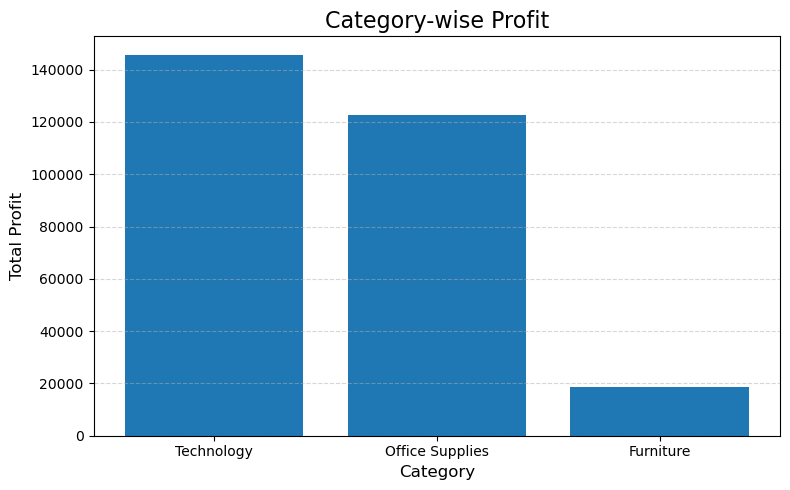

In [123]:
plt.figure(figsize=(8,5))
plt.bar(category_profit["Category"], category_profit["Profit"])
    
plt.title("Category-wise Profit", fontsize=16)

plt.xlabel("Category", fontsize=12)

plt.ylabel("Total Profit", fontsize=12)

plt.grid(axis="y", linestyle="--",alpha=0.5)

# for bar in bars:
#     plt.text(bar.get_x() + bar.get_width()/2,
#              bar.get_height(),
#              f'{bar.get_height():.0f}',
#              ha='center', va="bottom")
    
plt.tight_layout()

plt.savefig(
    "../visualizations/profits/profit_by_category.png",dpi=300, bbox_inches="tight"
)


plt.show()

# 4. Profit by Region

# Which region generated the highest profit?

In [124]:
region_profit =(df.groupby("Region")["Profit"].sum().sort_values(ascending=True).reset_index())
region_profit

,Region,Profit
0,Central,39706.3625
1,South,46749.4303
2,East,91522.7800
3,West,108418.4489


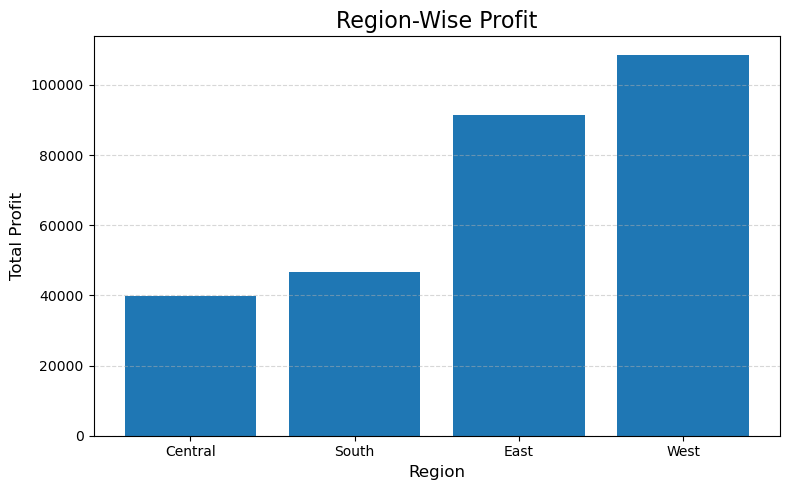

In [125]:
plt.figure(figsize=(8,5))

plt.bar(region_profit["Region"], region_profit["Profit"])

plt.title("Region-Wise Profit", fontsize=16)

plt.xlabel("Region", fontsize=12)

plt.ylabel("Total Profit", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(
    "../visualizations/profits/region_wise_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Monthly Profit Trend

# How does profit change month by month?

In [97]:
monthly_profit = (
    df.groupby("Month Name")["Profit"]
      .sum()
      .reindex([
          "January", "February", "March", "April",
          "May", "June", "July", "August",
          "September", "October", "November", "December"
      ])
      .reset_index()
)

monthly_profit

,Month Name,Profit
0,January,9134.4461
1,February,10294.6107
2,March,28594.6872
3,April,11587.4363
4,May,22411.3078
5,June,21285.7954
6,July,13832.6648
7,August,21776.9384
8,September,36857.4753
9,October,31784.0413


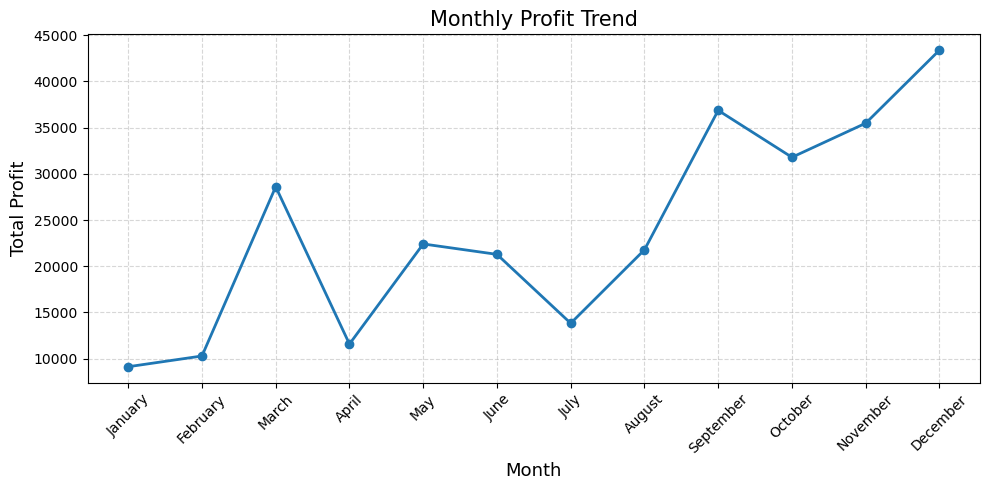

In [104]:
plt.figure(figsize=(10,5))

plt.plot(monthly_profit["Month Name"], monthly_profit["Profit"], marker="o",linewidth=2)

plt.title("Monthly Profit Trend", fontsize=15)

plt.xlabel("Month", fontsize=13)

plt.ylabel("Total Profit",fontsize=13)

plt.grid(True, linestyle="--", alpha=0.5)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../visualizations/profits/monthly_profit_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 6. Profit by Customer Segment

# Which customer segment generated the highest profit?

In [106]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Shipping Days', 'Year', 'Month', 'Month Name', 'Quarter', 'Day Name',
       'Profit Margin'],
      dtype='object')

In [109]:
customer_segment = (df.groupby("Segment")["Profit"].sum().reset_index())
customer_segment

,Segment,Profit
0,Consumer,134119.2092
1,Corporate,91979.1340
2,Home Office,60298.6785


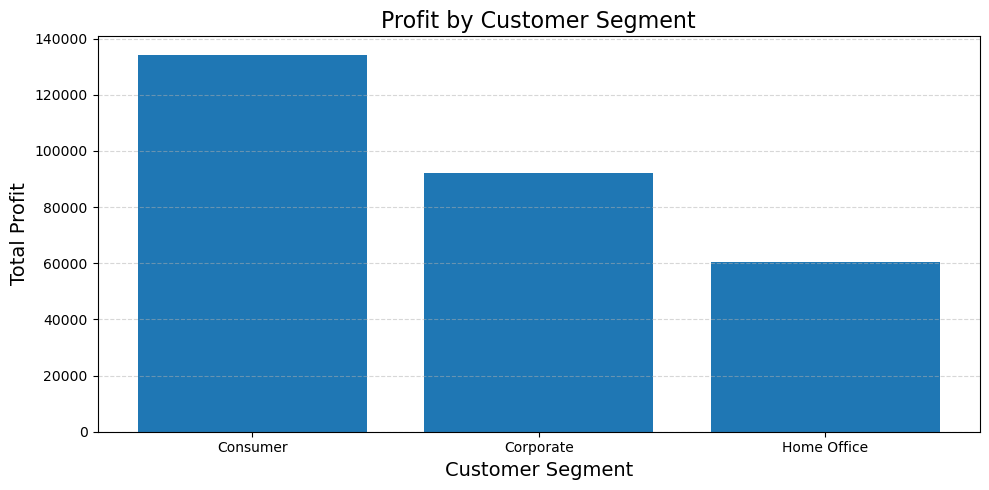

In [121]:
plt.figure(figsize=(10,5))
plt.bar(customer_segment["Segment"], customer_segment["Profit"])

plt.title("Profit by Customer Segment", fontsize=16)

plt.xlabel("Customer Segment", fontsize=14)

plt.ylabel("Total Profit", fontsize=14)

plt.grid(axis="y", linestyle="--",alpha=0.5)

plt.tight_layout()

plt.savefig(
    "../visualizations/profits/profit_by_customer_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Discount vs Profit

# Does higher discount reduce profit?


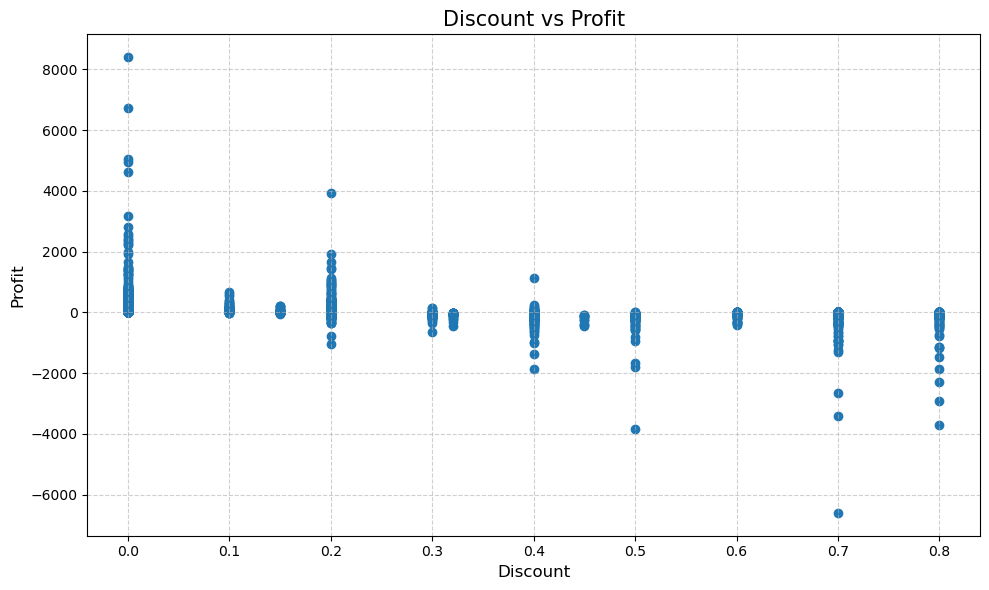

In [133]:
plt.figure(figsize=(10,6))

plt.scatter(df["Discount"], df["Profit"])

plt.title("Discount vs Profit", fontsize=15)

plt.xlabel("Discount", fontsize=12)

plt.ylabel("Profit", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()

plt.savefig(
    "../visualizations/profits/discount_vs_profit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Top 10 Products by Profit

In [135]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Shipping Days', 'Year', 'Month', 'Month Name', 'Quarter', 'Day Name',
       'Profit Margin'],
      dtype='object')

In [142]:
top10_profit_products  = (df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10).reset_index())
top10_profit_products 

,Product Name,Profit
0,Canon imageCLASS 2200 Advanced Copier,25199.9280
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.0390
2,Hewlett Packard LaserJet 3310 Copier,6983.8836
3,Canon PC1060 Personal Laser Copier,4570.9347
4,HP Designjet T520 Inkjet Large Format Printer ...,4094.9766
5,Ativa V4110MDD Micro-Cut Shredder,3772.9461
6,"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714
7,Plantronics Savi W720 Multi-Device Wireless He...,3696.2820
8,Ibico EPK-21 Electric Binding System,3345.2823
9,Zebra ZM400 Thermal Label Printer,3343.5360


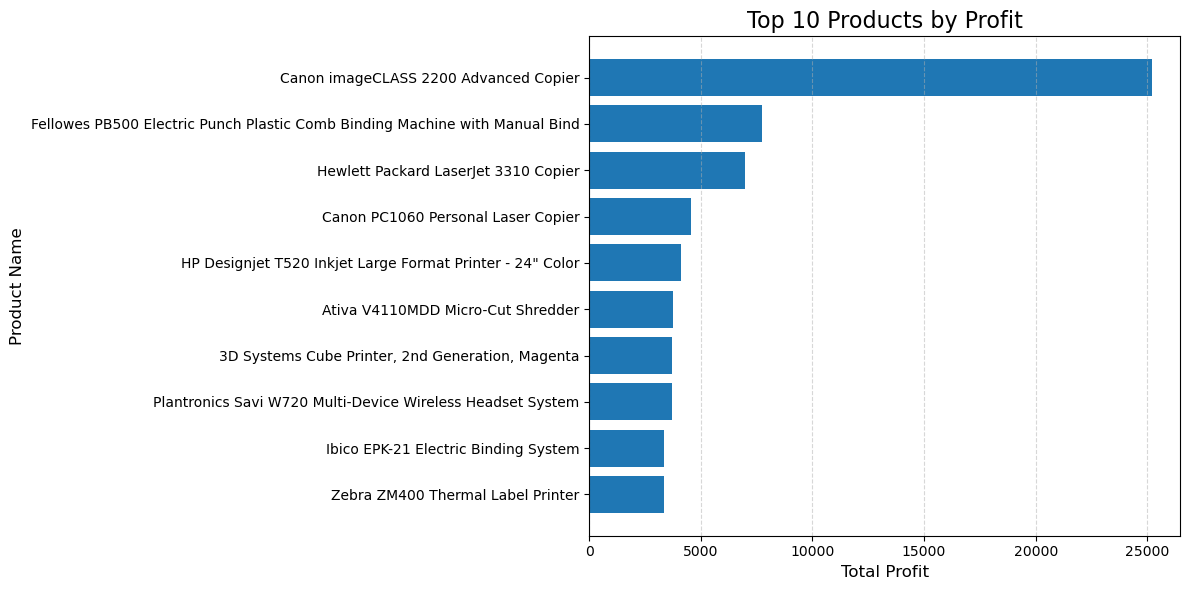

In [156]:
plt.figure(figsize=(12,6))

bars = plt.barh(top10_profit_products["Product Name"], top10_profit_products["Profit"])

plt.gca().invert_yaxis()

plt.title("Top 10 Products by Profit", fontsize=16)

plt.xlabel("Total Profit", fontsize=12)

plt.ylabel("Product Name", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig(
    "../visualizations/profits/top10_profit_products.png", dpi=300, bbox_inches="tight"
)


plt.show()

## Business Insight

- The top 10 products contribute a significant portion of the total profit.
- These products are the company's most profitable offerings.
- Maintaining inventory for these products is essential to maximize profitability.

# 9. Top 10 Loss-Making Products

# Which products generated the highest loss?

In [168]:
top10_loss_products = (df.groupby("Product Name")["Profit"].sum().sort_values(ascending=True).head(10).reset_index())
top10_loss_products

,Product Name,Profit
0,Cubify CubeX 3D Printer Double Head Print,-8879.9704
1,Lexmark MX611dhe Monochrome Laser Printer,-4589.9730
2,Cubify CubeX 3D Printer Triple Head Print,-3839.9904
3,Chromcraft Bull-Nose Wood Oval Conference Tabl...,-2876.1156
4,Bush Advantage Collection Racetrack Conference...,-1934.3976
5,GBC DocuBind P400 Electric Binding System,-1878.1662
6,Cisco TelePresence System EX90 Videoconferenci...,-1811.0784
7,Martin Yale Chadless Opener Electric Letter Op...,-1299.1836
8,Balt Solid Wood Round Tables,-1201.0581
9,BoxOffice By Design Rectangular and Half-Moon ...,-1148.4375


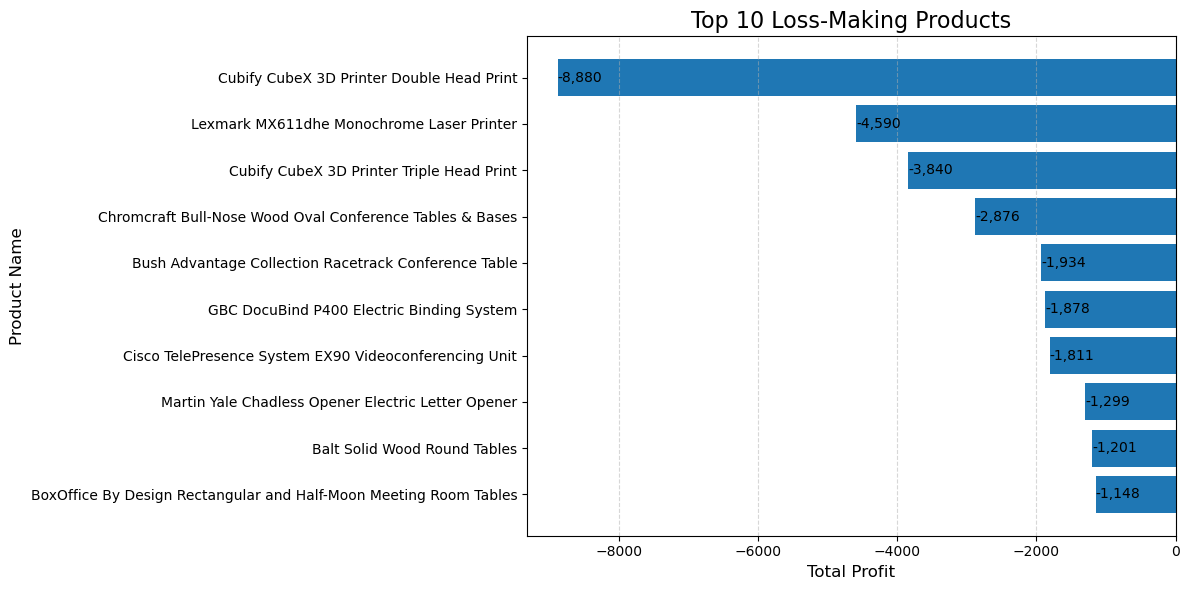

In [181]:
plt.figure(figsize=(12,6))
bars = plt.barh(top10_loss_products["Product Name"], top10_loss_products["Profit"])

plt.gca().invert_yaxis()

plt.title("Top 10 Loss-Making Products", fontsize=16)

plt.xlabel("Total Profit", fontsize=12)

plt.ylabel("Product Name", fontsize=12)

plt.grid(axis="x",linestyle="--",alpha=0.5)

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():,.0f}',
        va='center'
    )

plt.tight_layout()

# Save Chart
plt.savefig(
    "../visualizations/profits/top10_loss_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Insight

- The listed products generated the highest losses for the business.
- These products negatively impact overall profitability.
- High discounts, low selling prices, or high operational costs may be contributing factors.

# Profit Distribution

# How is profit distributed across all orders?

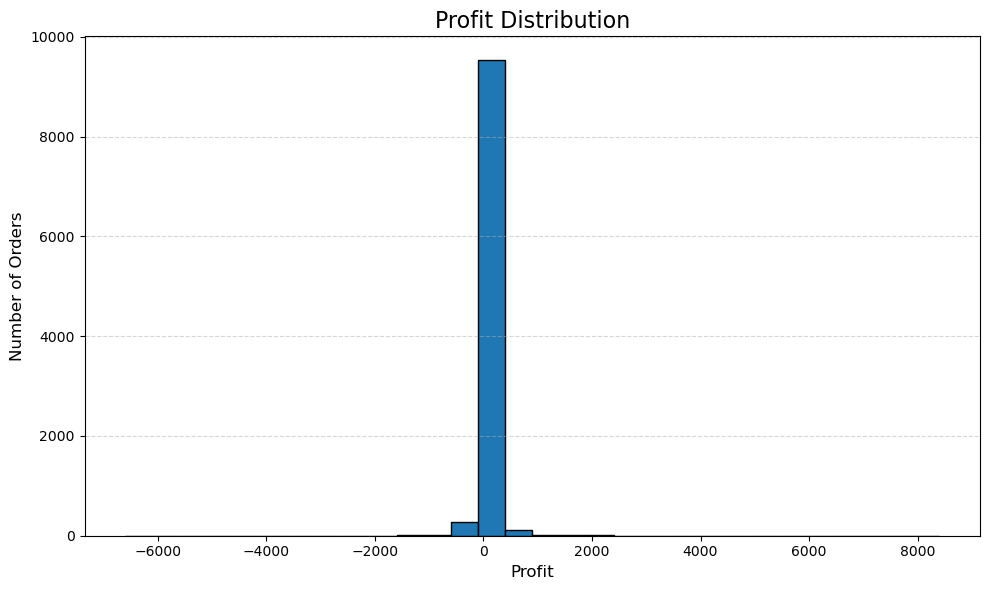

In [189]:

# Create Figure
plt.figure(figsize=(10,6))

# Histogram
plt.hist(
    df["Profit"],
    bins=30,
    edgecolor="black"
)

# Title
plt.title("Profit Distribution", fontsize=16)

# X-axis Label
plt.xlabel("Profit", fontsize=12)

# Y-axis Label
plt.ylabel("Number of Orders", fontsize=12)

# Grid
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Tight Layout
plt.tight_layout()

# Save Chart
plt.savefig(
    "../visualizations/profits/profit_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

# Show Chart
plt.show()